In [1]:
%matplotlib ipympl
import sys
import os
sys.path.append("../src/")
import matplotlib.pyplot as plt

import cdsaxs
import numpy as np

import cdsaxs.loaders
import cdsaxs.loaders.load_data
import cdsaxs.data
import cdsaxs.plotting


In [2]:
# set the path to the CSV metadata file for the validation data and create the dataset
csv_path = os.path.abspath("data_W204_F2/W204_metadata.csv")

In [3]:
dataset = cdsaxs.loaders.load_data.LoadDataset_MetadataCSV('validation', csv_path)

Loading files: 100%|█████████████████████████| 121/121 [00:02<00:00, 41.17it/s]

The following metadta is missing to calculate q: ['center_px', 'pixel_size_um']
Insufficient metadata to calculate q. Check your metadata to ensure the correct center position, wavelength, sample to detector distance, and pixel size are provided.
Created dataset from data directory: C:\Users\cmw5\Documents\github_repos\nist_cdsaxs\validation\data_W204_F2
and csv file W204_metadata.csv.


In [4]:
# use identical beam center position and sample-to-detector position as the GUI
# set the pixel size for Pilatus detector
dataset.update_all_metadata({'sdd_cm': 504.982, 'center_px': [738, 492], 'pixel_size_um': 172}, overwrite=True)

The images will be rotated in this workflow to align the data with the qy and qx coordinate conventions in the GUI:

<div>
<img src="GUI_Screenshot_ImageOrientation.png" width="500"/>
</div>

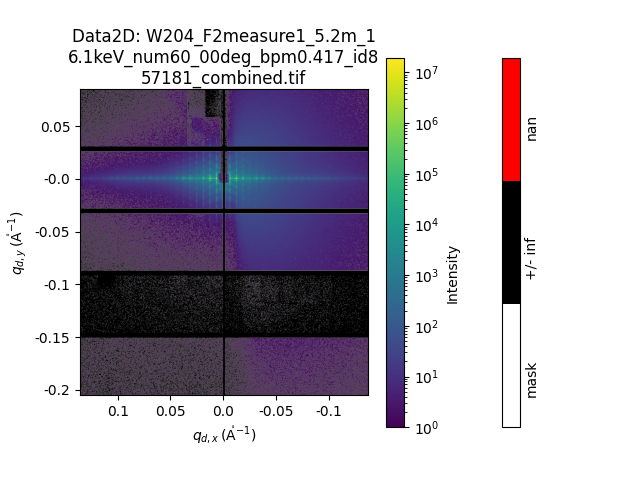

In [5]:
# rotate all images by 180 degrees to match GUI axis alignments
for data in dataset.datas.values():
    data.rotate_image_ccw(2)

data = dataset.datas["W204_F2measure1_5.2m_16.1keV_num60_00deg_bpm0.417_id857181_combined.tif"]
fig = data.plot_data()

In [6]:
data.metadata

{'sample_phi_deg': 0.0,
 'energy_ev': 16100.0,
 'wavelength_nm': 0.07700882268401864,
 'exposure_time_s': 2.0,
 'sdd_cm': 504.982,
 'data_directory': 'C:\\Users\\cmw5\\Documents\\github_repos\\nist_cdsaxs\\validation\\data_W204_F2',
 'filename': 'W204_F2measure1_5.2m_16.1keV_num60_00deg_bpm0.417_id857181_combined.tif',
 'sample_phi_offset_deg': 0,
 'center_px': (304, 488),
 'pixel_size_um': 172}

In [7]:
# normalize by count time
dataset.normalize_all_data_by_metadata(['exposure_time_s'])

C:\Users\cmw5\Documents\github_repos\nist_cdsaxs\validation\../src\cdsaxs\plotting\plotting.py:229: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\cmw5\Documents\github_repos\nist_cdsaxs\validation\../src\cdsaxs\plotting\plotting.py:182: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(
C:\Users\cmw5\Documents\github_repos\nist_cdsaxs\validation\../src\cdsaxs\plotting\plotting.py:229: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


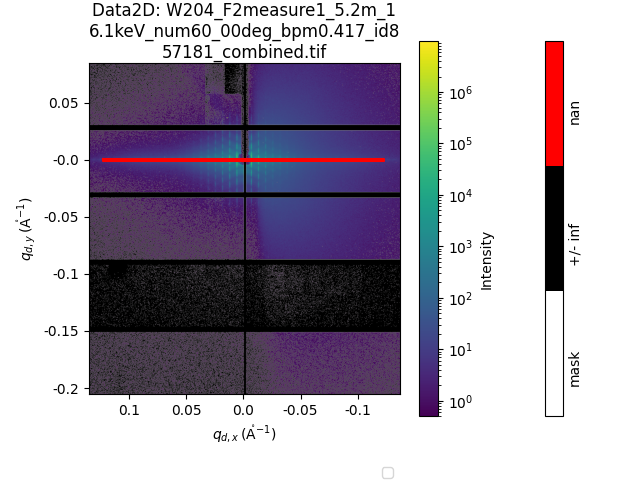

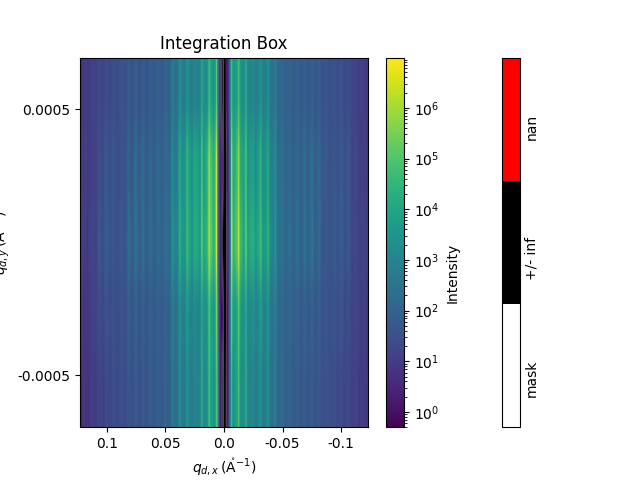

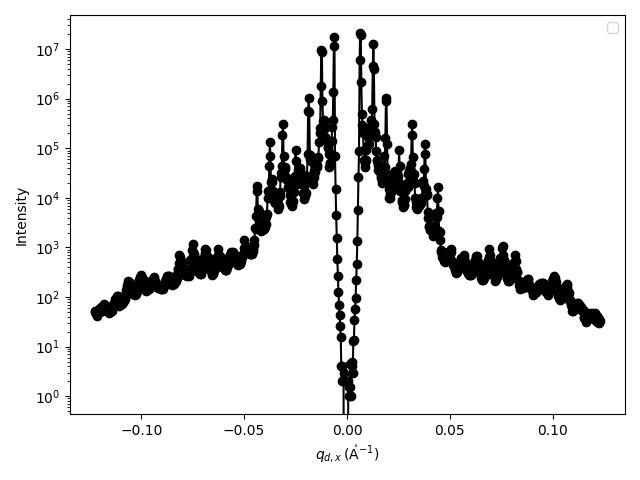

In [8]:
qslice = data.integrate_box(5, 884, mode='sum')

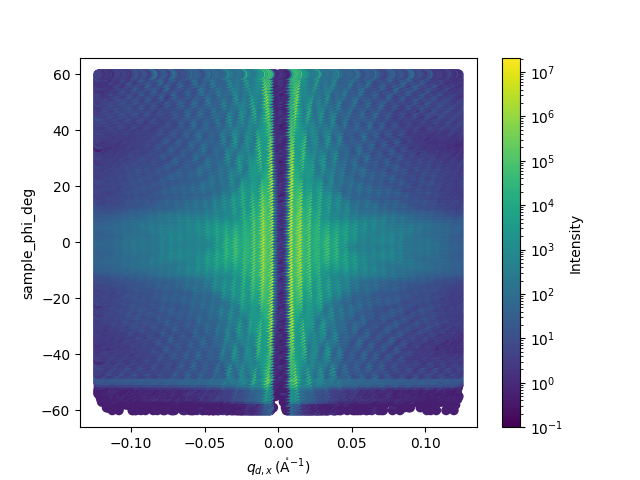

In [16]:
integrated_dataset = dataset.integrate_dataset(5, 884, mode='sum', axis='qdy')
fig = cdsaxs.plotting.plotting.plot_integrated_dataset(integrated_dataset)

In [17]:
reduced_dataset = cdsaxs.reduction.reduce_dataset(integrated_dataset)

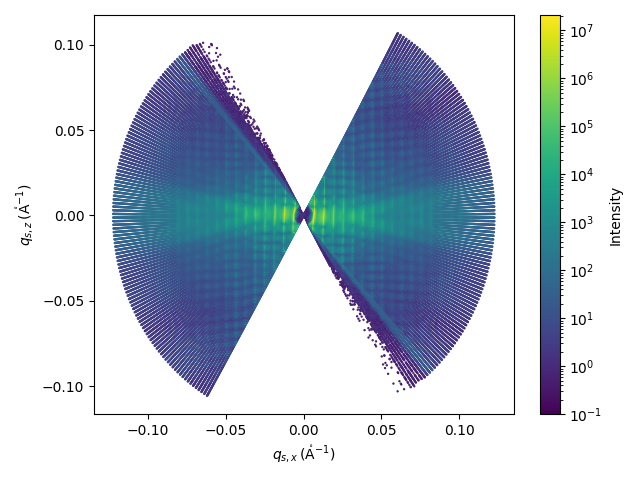

In [23]:
fig = cdsaxs.plotting.plotting.plot_reduced_dataset(reduced_dataset, interpolated_data=False, s=0.5)

C:\Users\cmw5\Documents\github_repos\nist_cdsaxs\validation\../src\cdsaxs\plotting\plotting.py:959: UserWarning: Log scale: values of z <= 0 have been masked
  data_plot = plt.contourf(
C:\Users\cmw5\Documents\github_repos\nist_cdsaxs\validation\../src\cdsaxs\plotting\plotting.py:959: UserWarning: The following kwargs were not used by contour: 's'
  data_plot = plt.contourf(


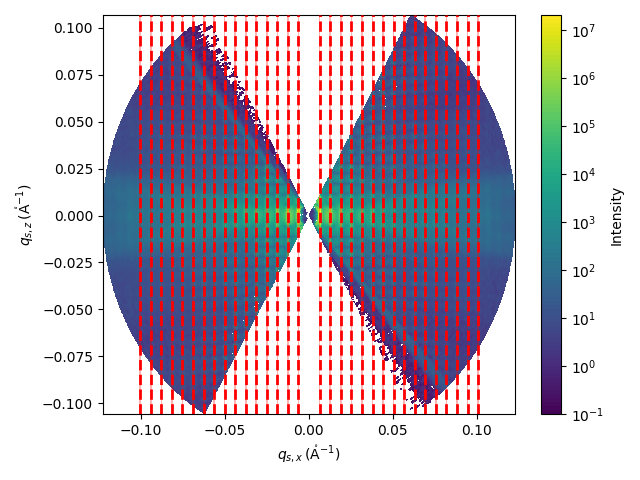

In [26]:
# the slice points (q_values) matches the slices taken in the GUI
q_values = np.array([0.006441, 0.01275, 0.01904, 0.02532, 0.03156, 0.03788, 0.04412, 0.05044, 0.05672, 0.06294, 0.06923, 0.07553, 0.08187, 0.08805, 0.09442, 0.1007, -0.006155, -0.01249, -0.01871, -0.02496, -0.03124, -0.03751, -0.04373, -0.05005, -0.0563, -0.06248, -0.06883, -0.07513, -0.08133, -0.08767, -0.09397, -0.1003]) 
reduced_slices, fig = cdsaxs.reduction.slice_reduced_dataset(reduced_dataset, q_values=q_values, q_widths=0.001, plotting_kwargs={'s': 0.5, 'interpolated_data': True})

In [36]:
# the dictionary of reduced slices from the refactored code will be referenced as 'refactored_slices'
refactored_slices = {}
for data in reduced_slices.data:
    refactored_slices[float(data.qsx)] = data

In [46]:
# load the reduced slices from the legacy gui as 'legacy_slices'
legacy_file = "LegacyGUISlices_LargerWidthSlices0p001_20250509.csv"
file = open(legacy_file)
data = file.readlines()
file.close()
data = [x.split(',') for x in data]
data = np.array(data, dtype=str)
header = data[0, :]

legacy_slices = {}

for i in range(0, int(header.shape[0]/2)):
    qz = data[1:, i*2]
    iqz = data[1:, i*2+1]

    selection = np.where(qz!='')

    qz = qz[selection].astype(np.float64)
    iqz = iqz[selection].astype(np.float64)

    head = header[i*2+1]
    head = head.split('=')
    head = head[-1]
    if head[-2:] == '\n':
        head = head[:-2]

    qx = np.float64(head)

    legacy_slices[float(np.round(qx, 4))] = cdsaxs.data.data1d.Data1D(q=qz, Iq=iqz, q_axis='qsz')

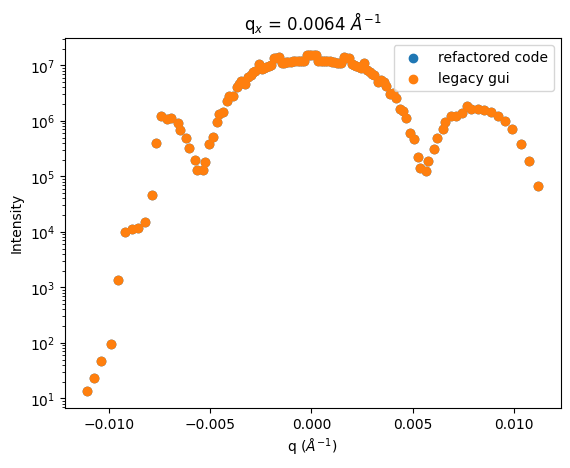

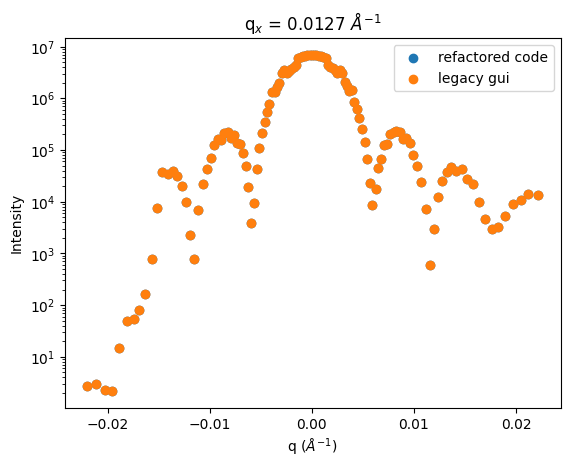

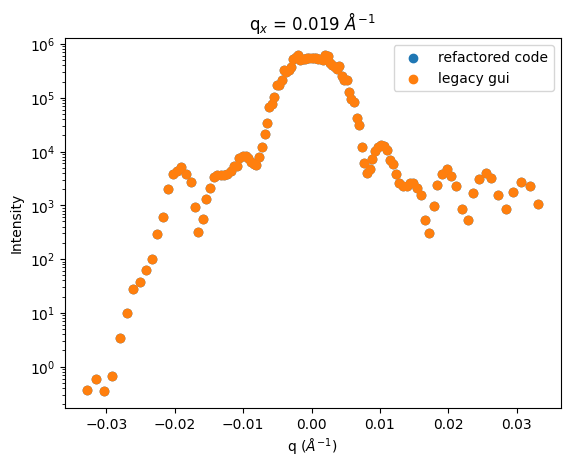

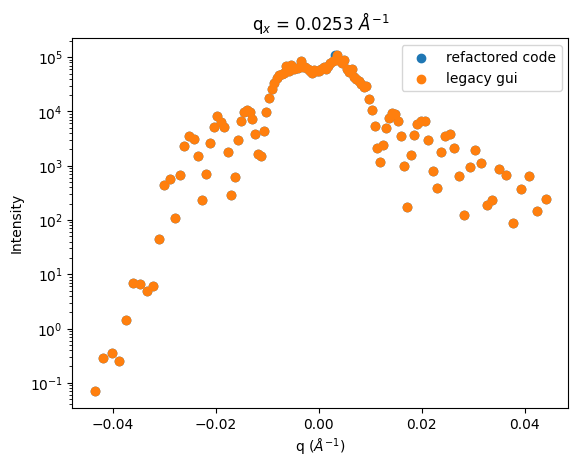

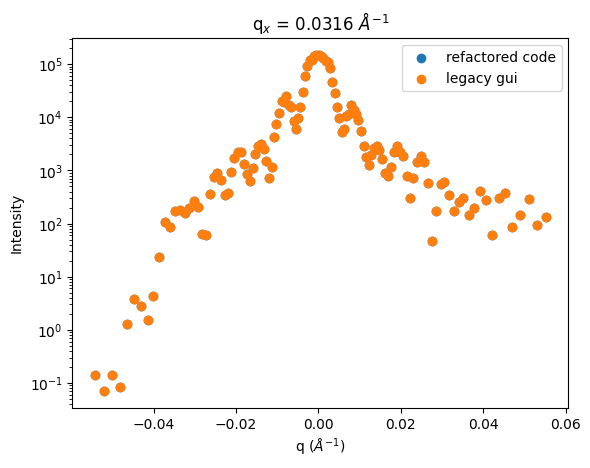

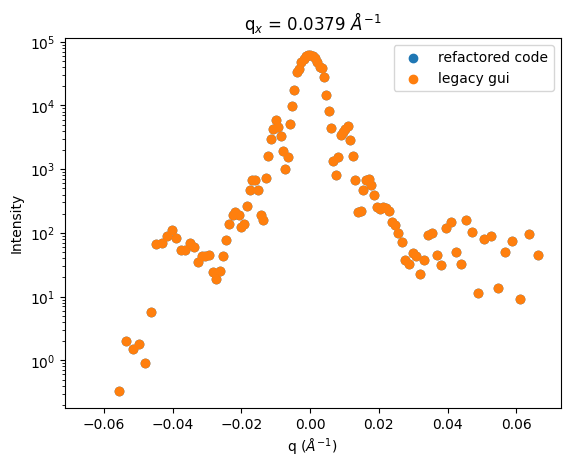

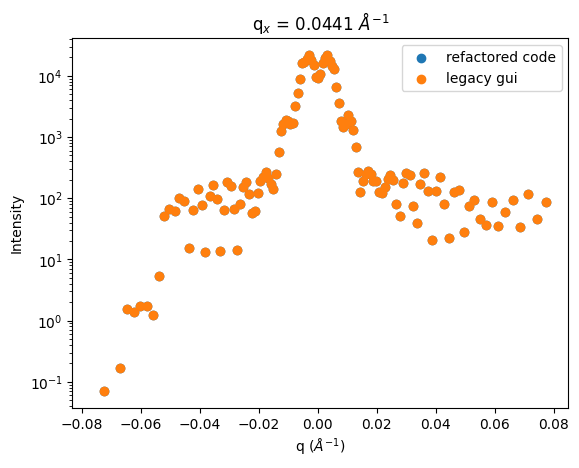

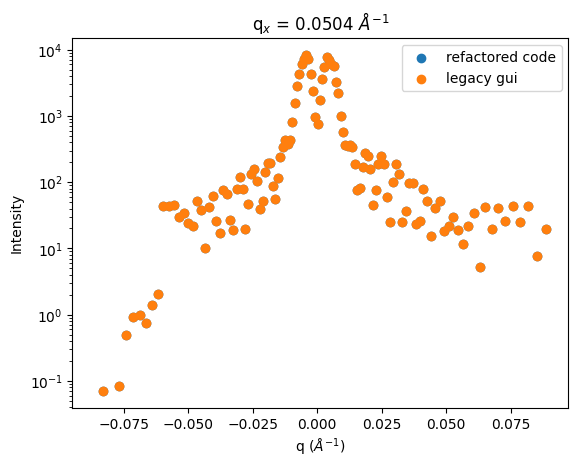

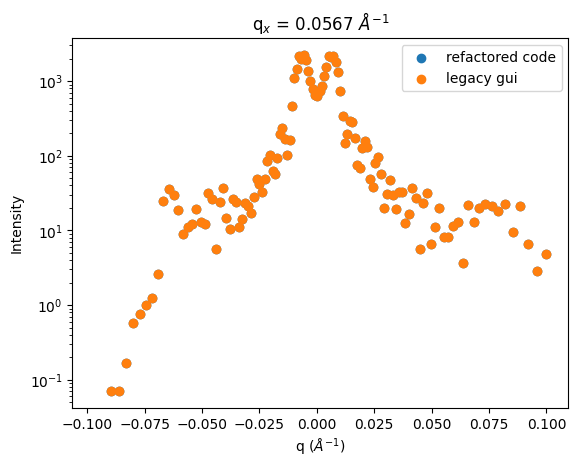

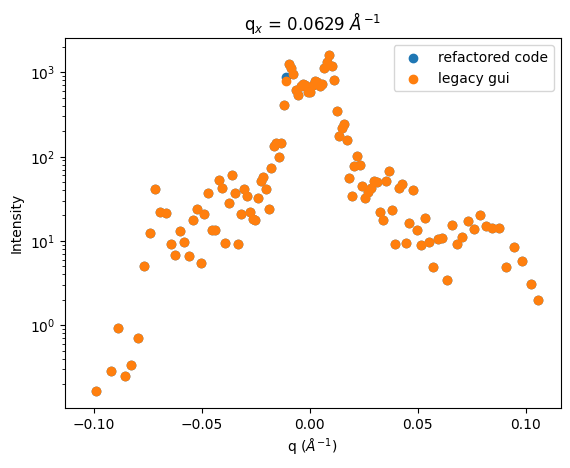

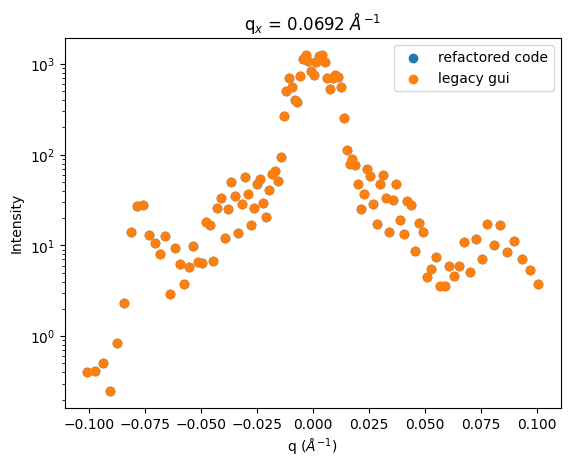

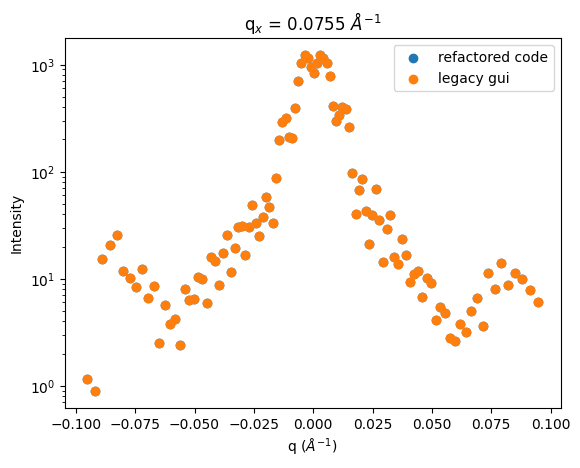

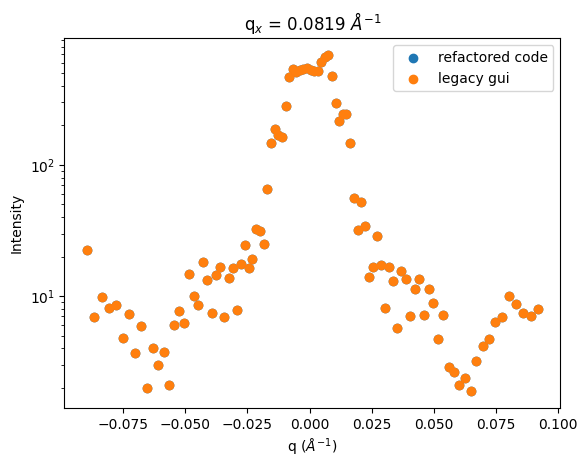

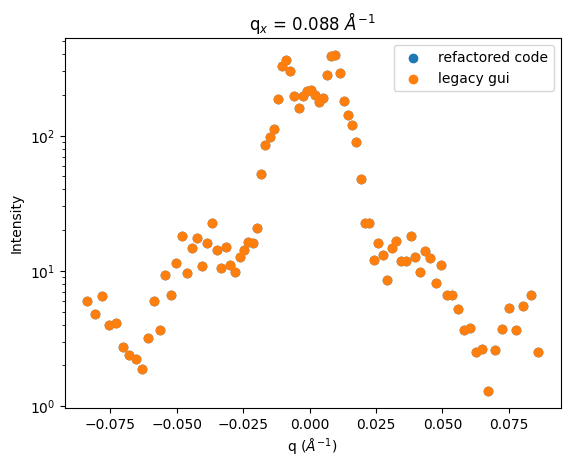

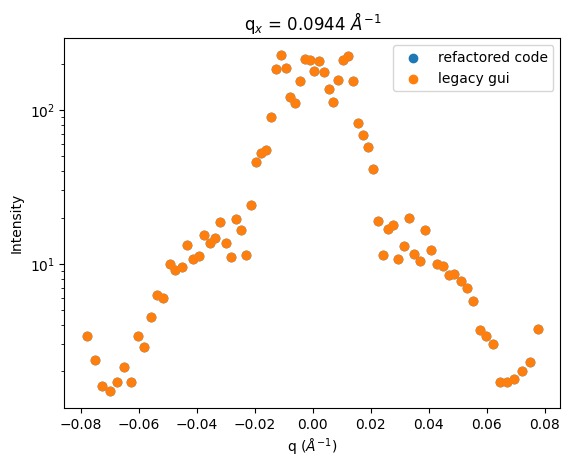

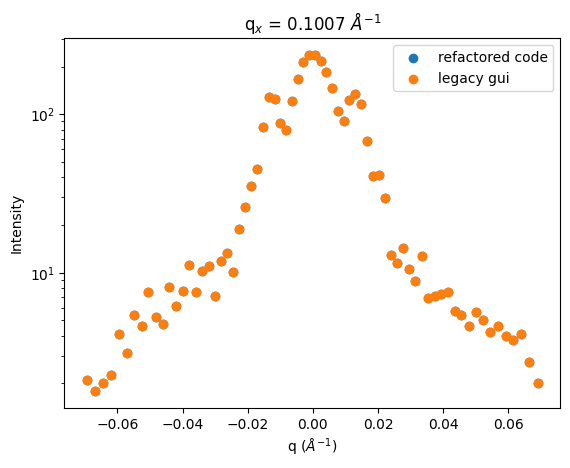

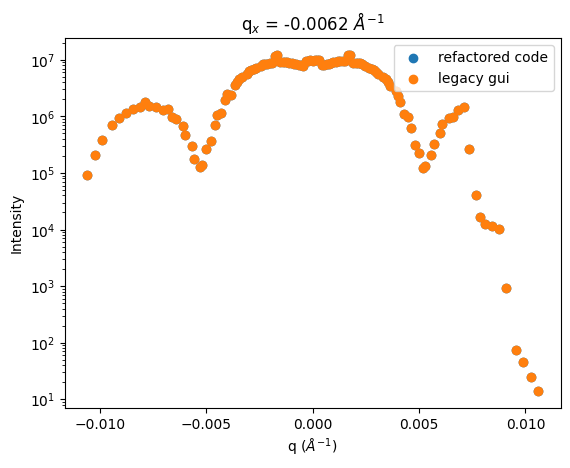

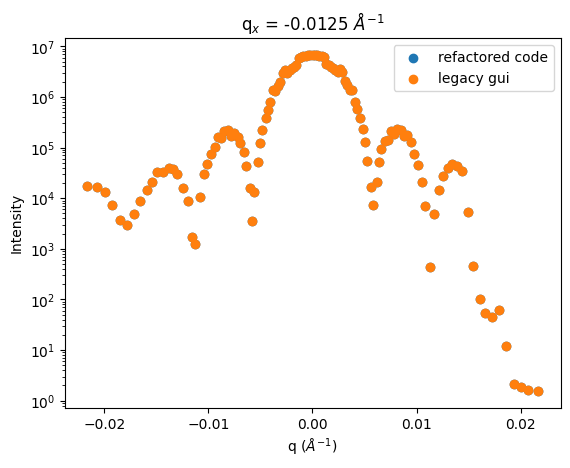

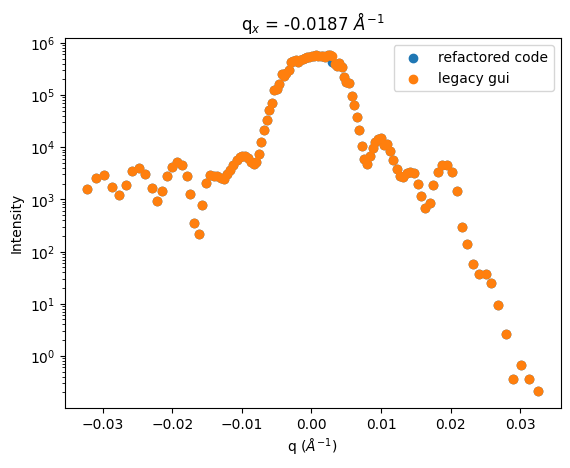

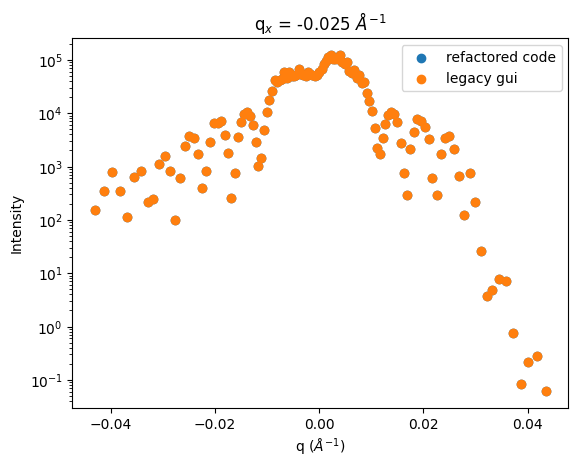

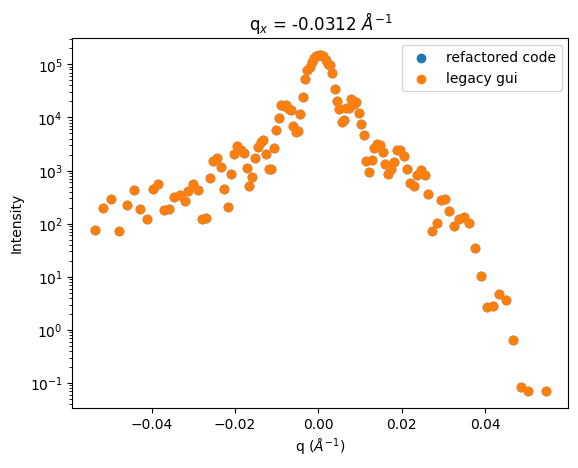

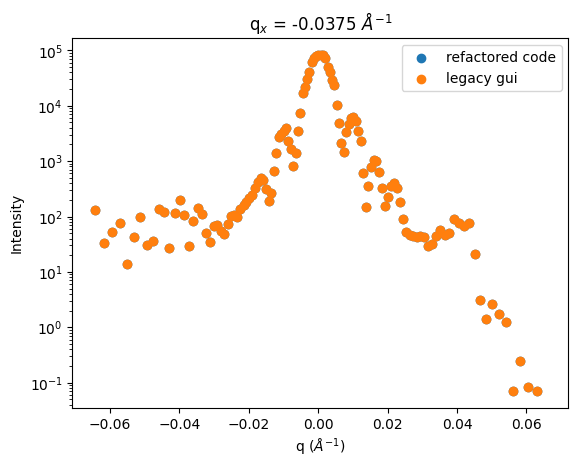

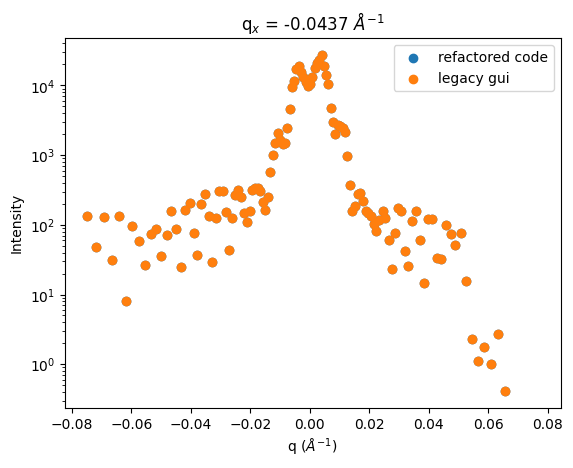

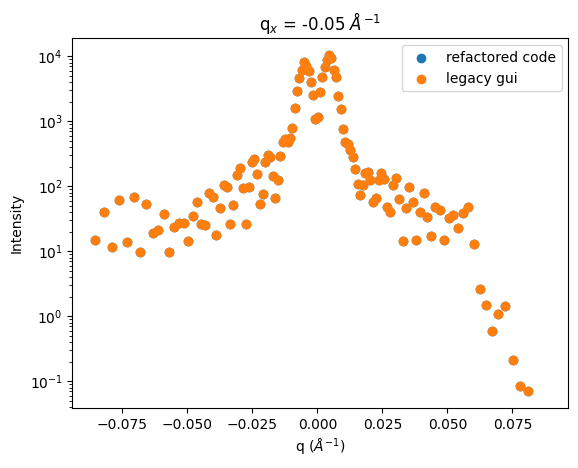

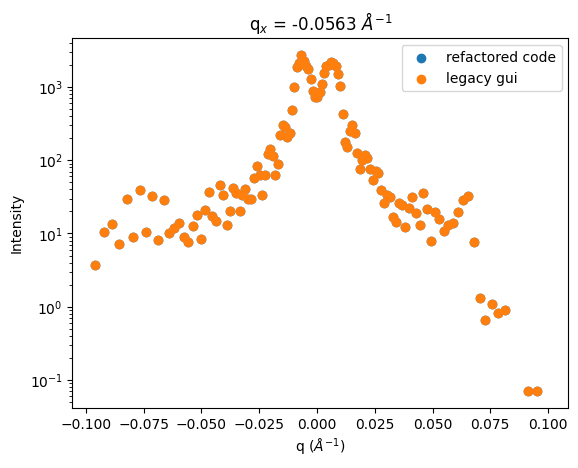

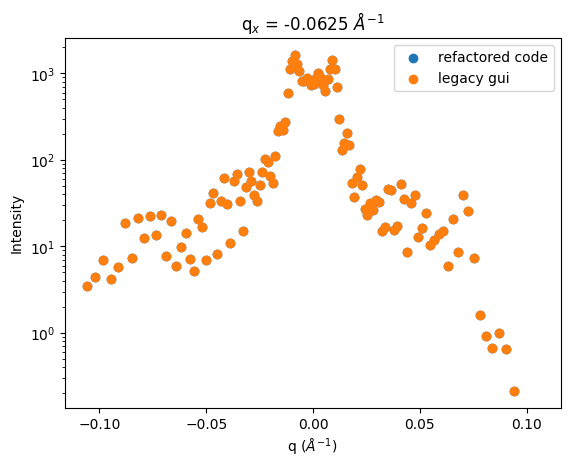

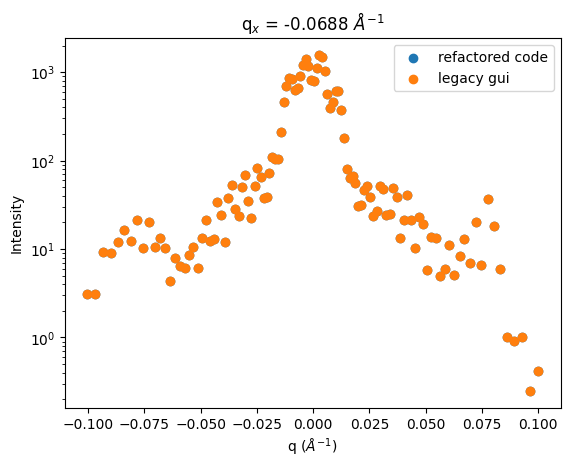

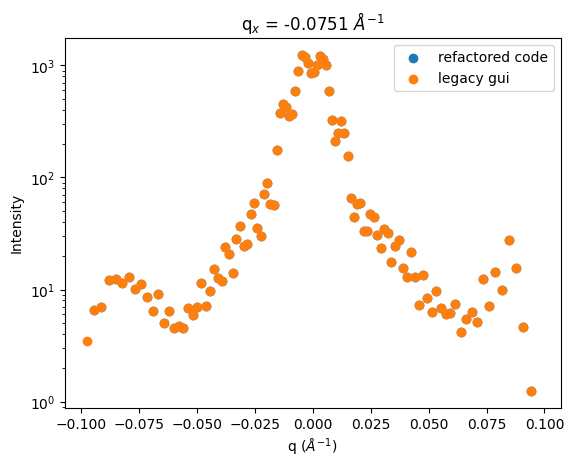

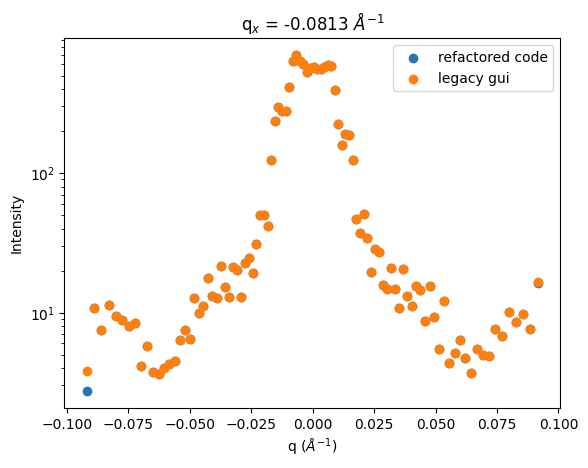

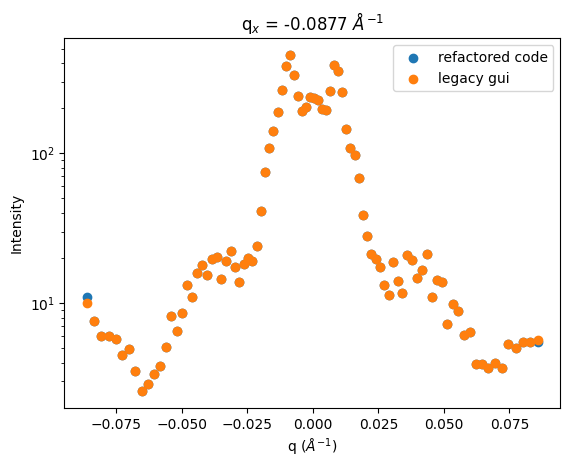

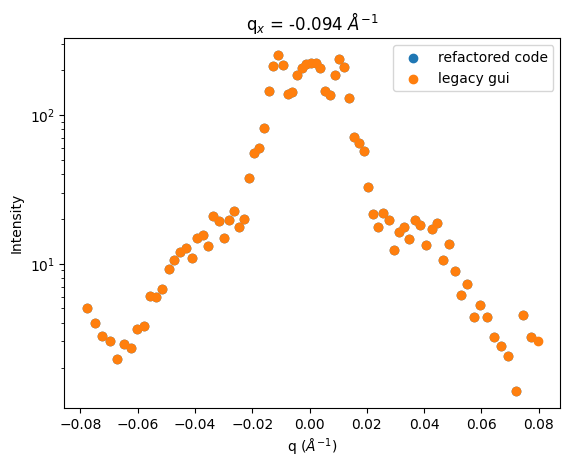

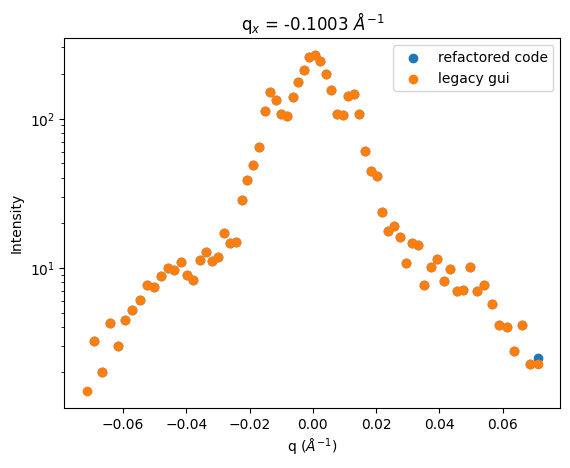

In [52]:
%matplotlib inline
# plot each slice from the refactored code with the matching slice from the legacy gui
for qx in legacy_slices.keys():
    plt.figure()
    slice_legacy = legacy_slices[qx]
    slice_refactor = refactored_slices[qx]
    
    plt.scatter(slice_refactor.q, slice_refactor.Iq, label='refactored code')
    plt.scatter(slice_legacy.q, slice_legacy.Iq, label='legacy gui')

    plt.legend()

    # plt.xlim(-0.001, 0.001)
    
    plt.title(r"q$_x$ = "+str(qx)+r" $\AA^{-1}$")
    plt.ylabel("Intensity")
    plt.xlabel(r"q ($\AA^{-1}$)")
    plt.yscale('log')
    plt.show()
    plt.close()

    # break

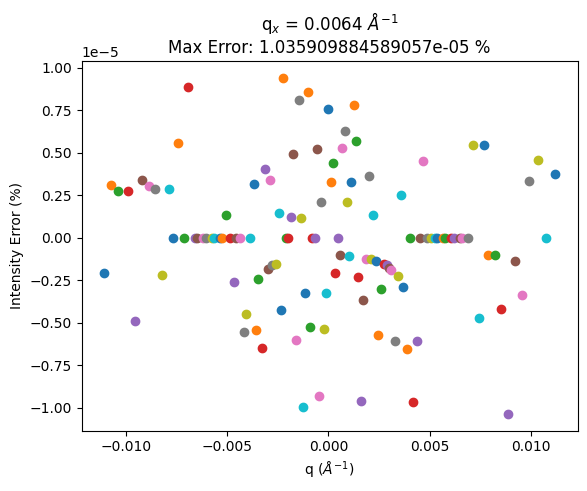

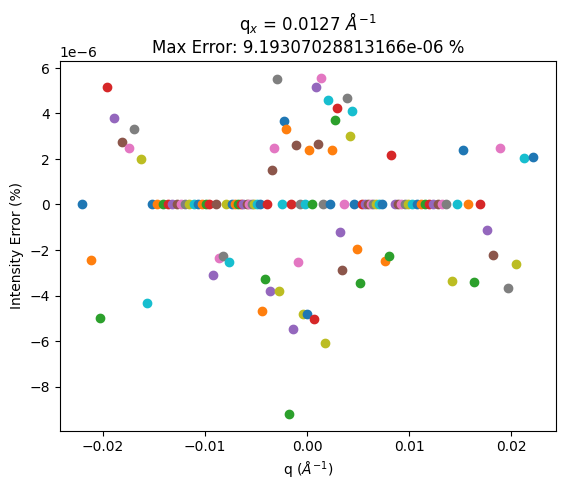

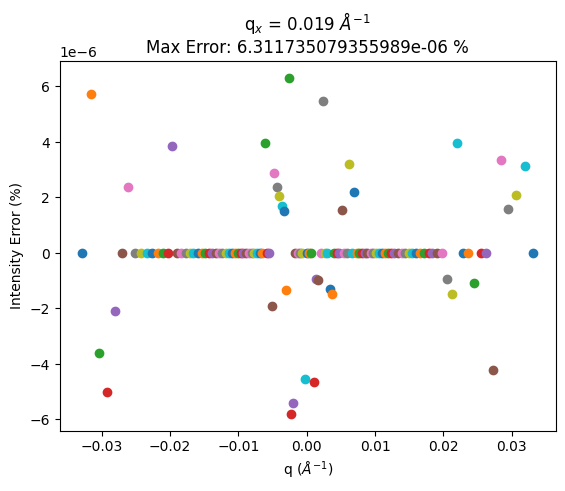

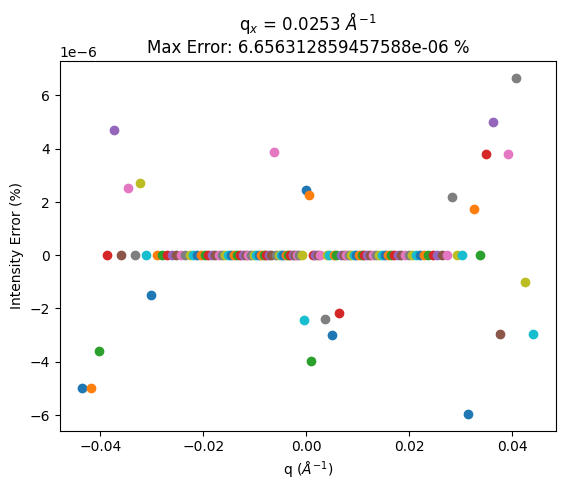

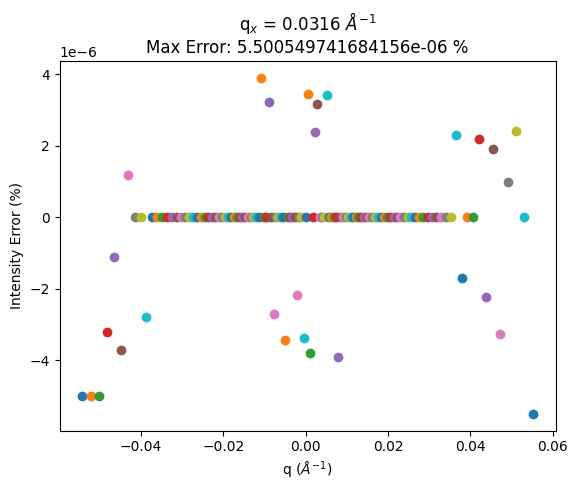

C:\Users\cmw5\AppData\Local\Temp\ipykernel_35408\46487735.py:17: RuntimeWarning: invalid value encountered in scalar divide
  error = (slice_refactor.Iq[close_match] - slice_legacy.Iq[i])*100/slice_legacy.Iq[i]


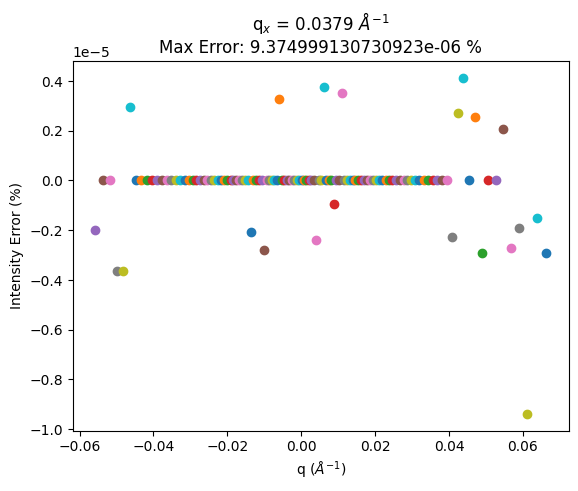

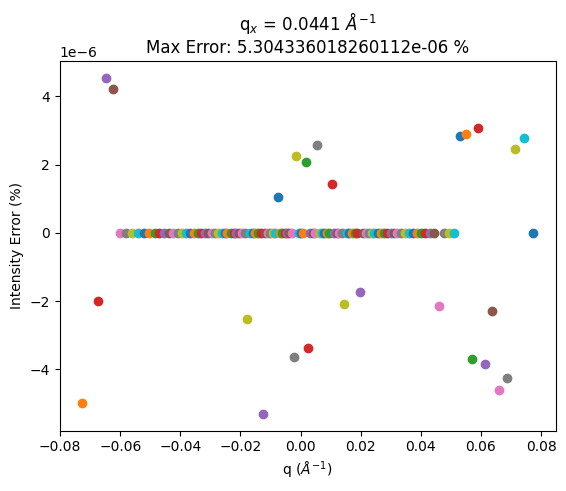

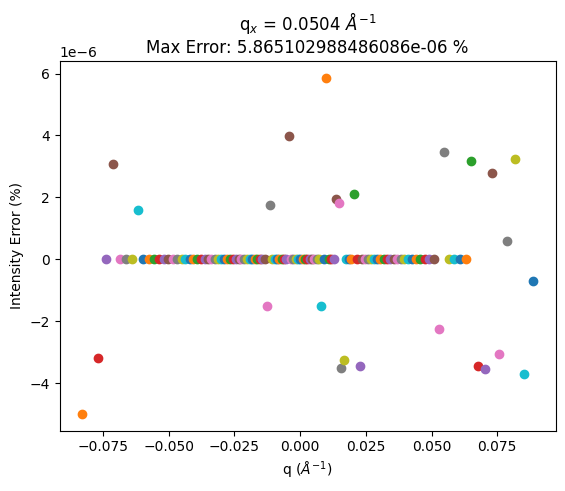

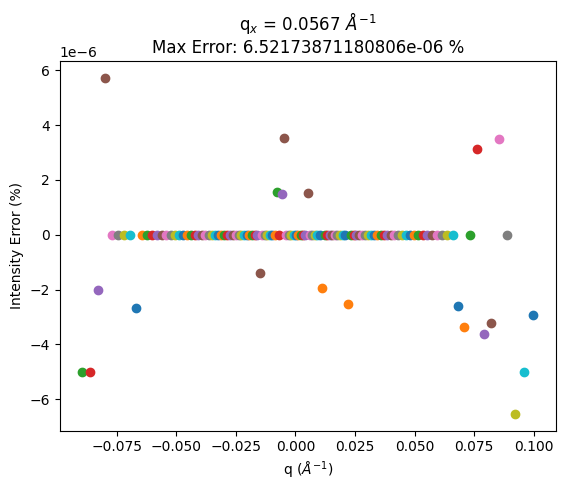

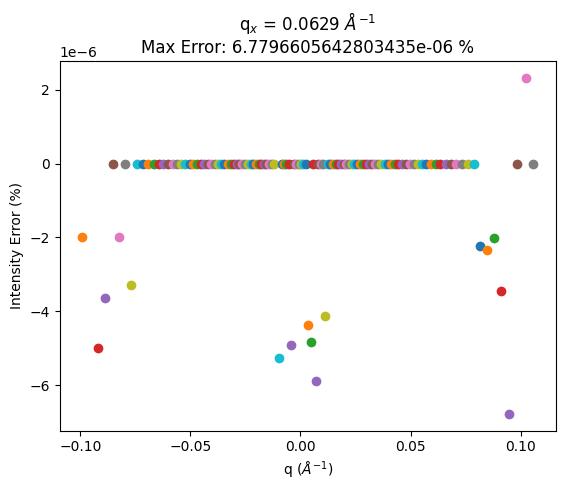

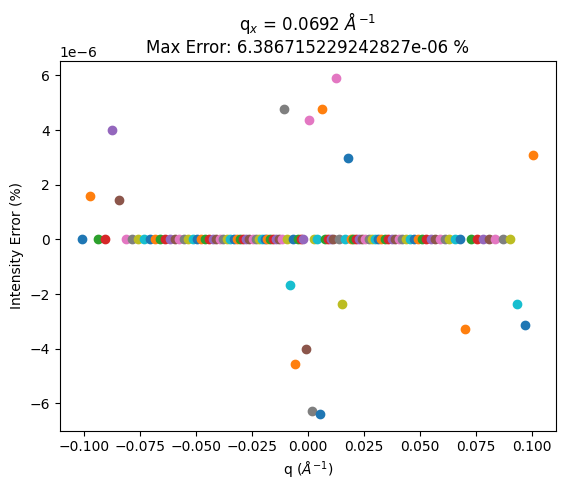

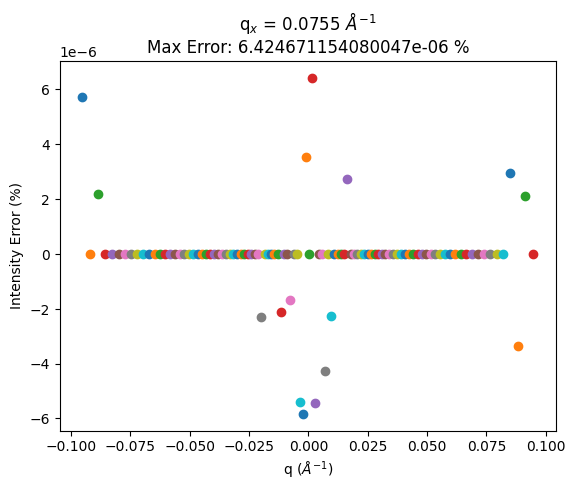

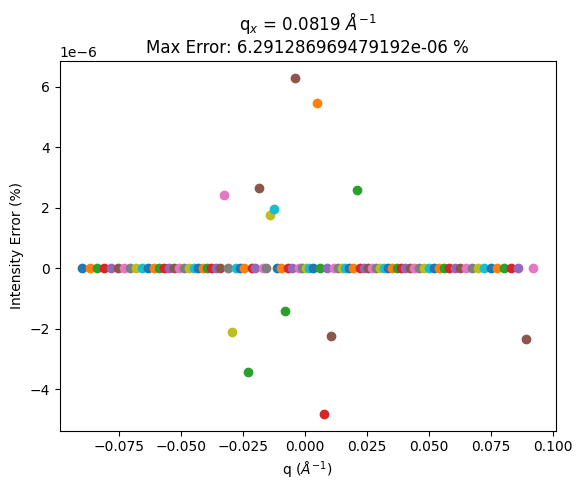

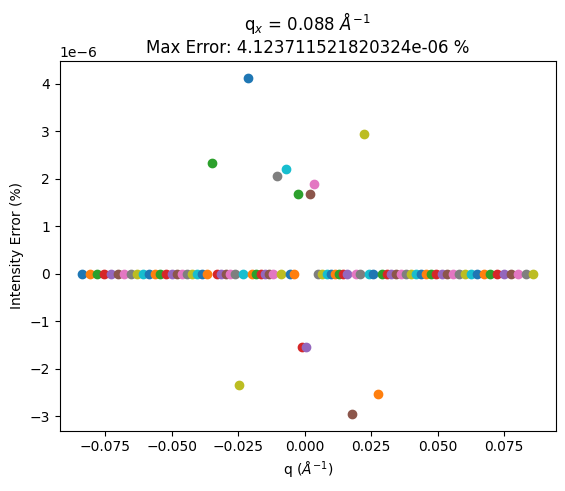

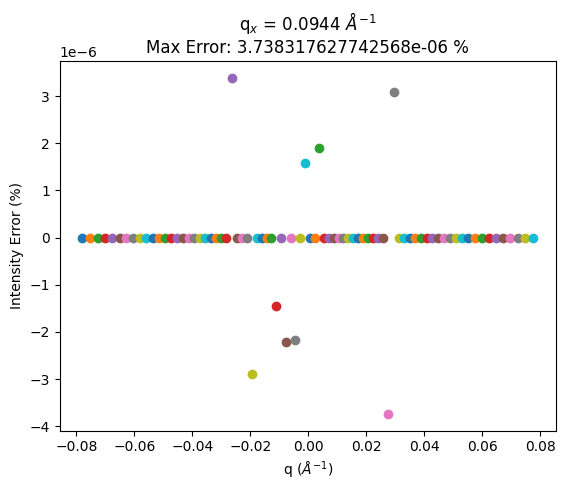

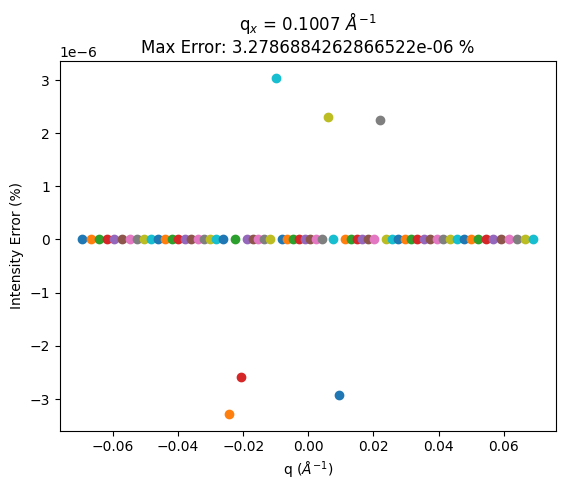

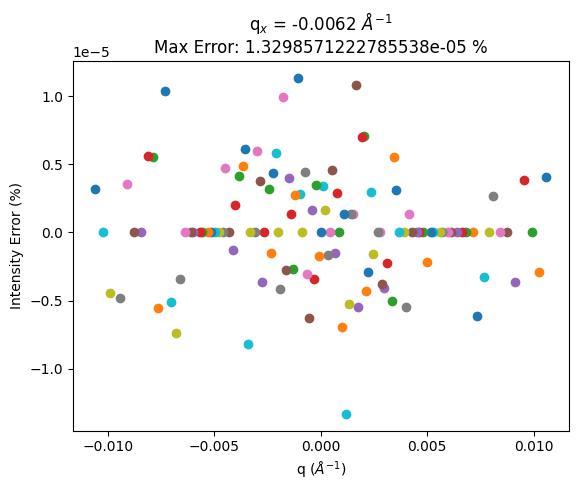

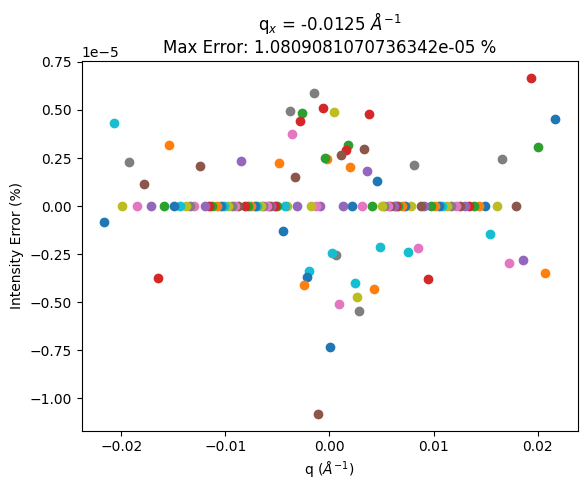

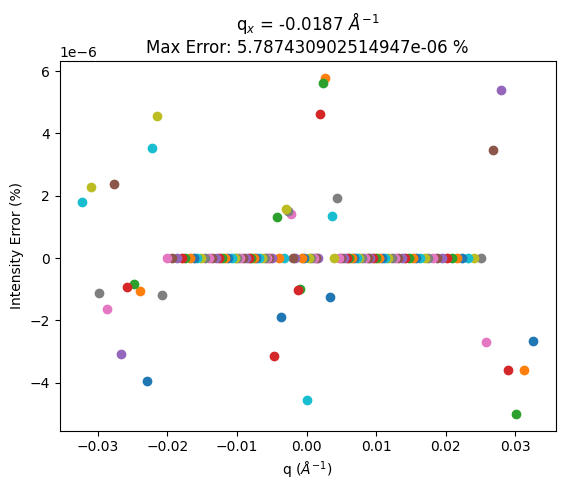

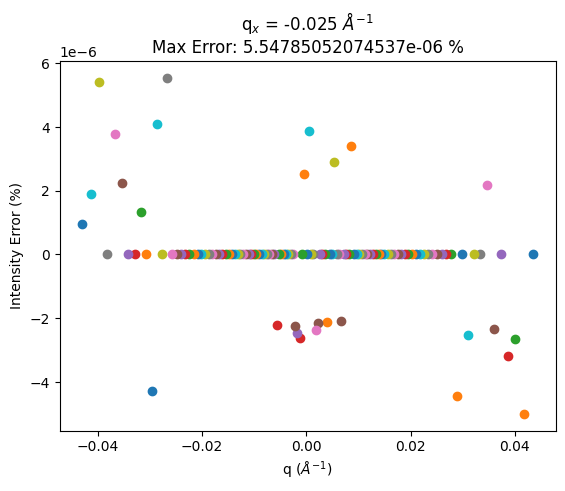

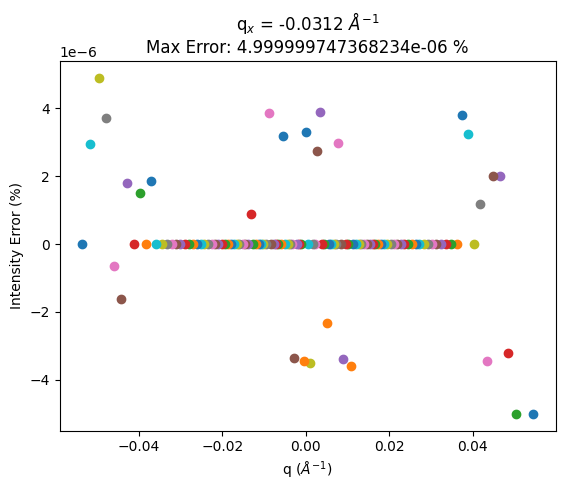

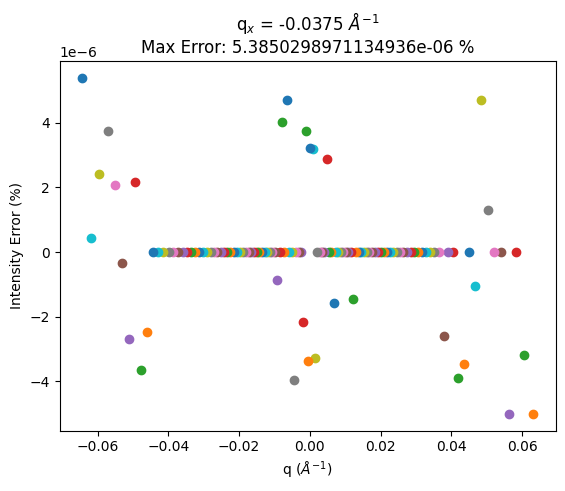

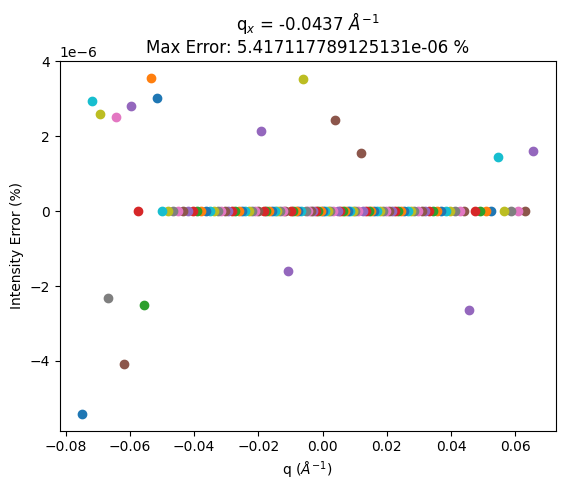

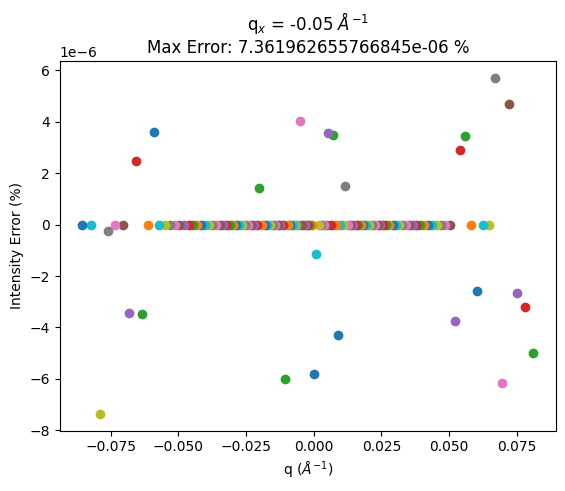

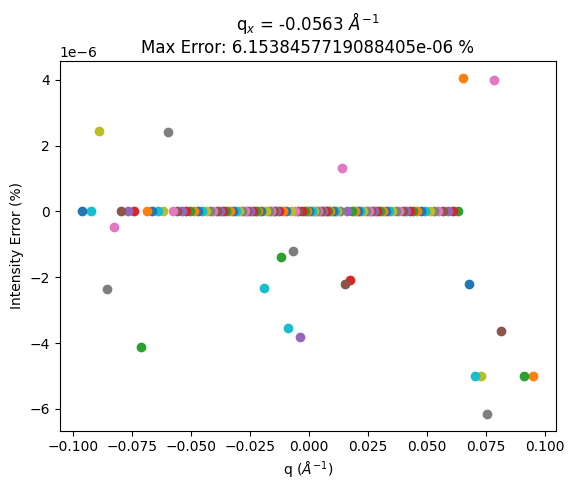

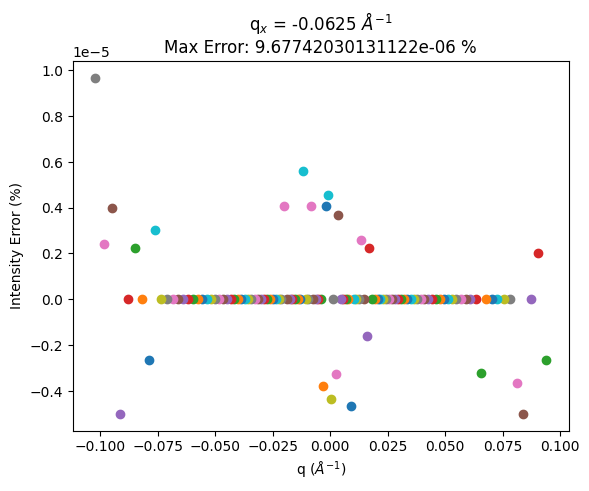

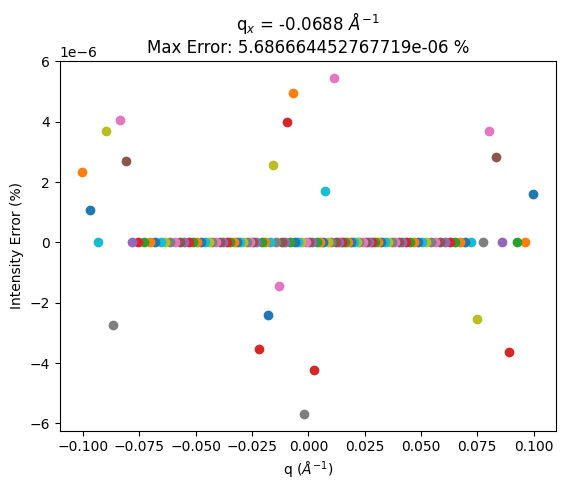

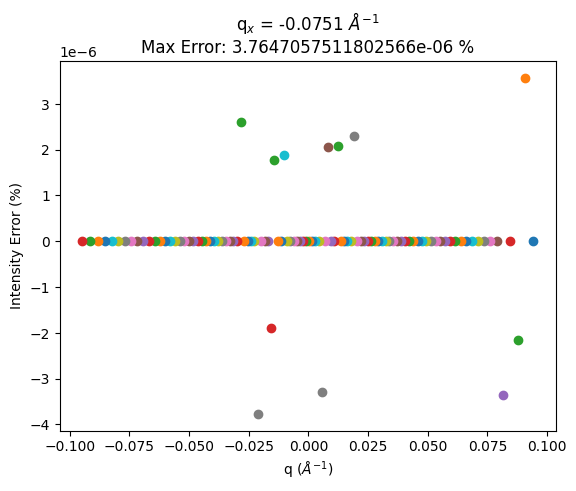

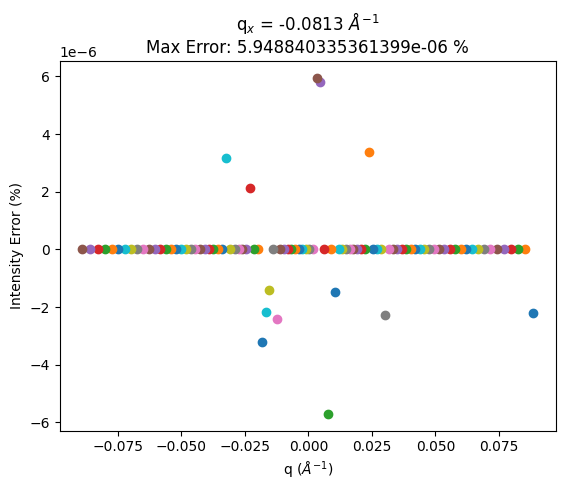

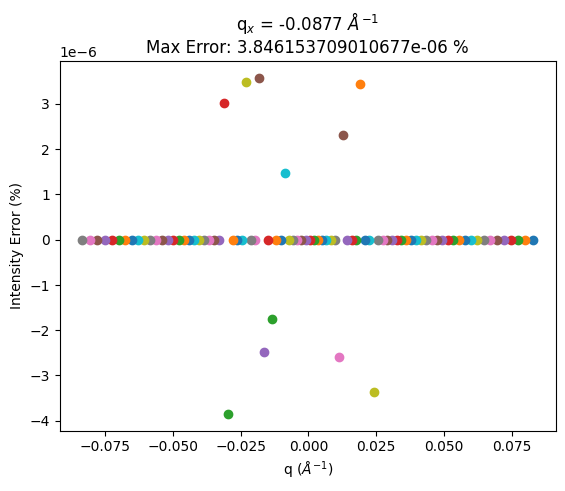

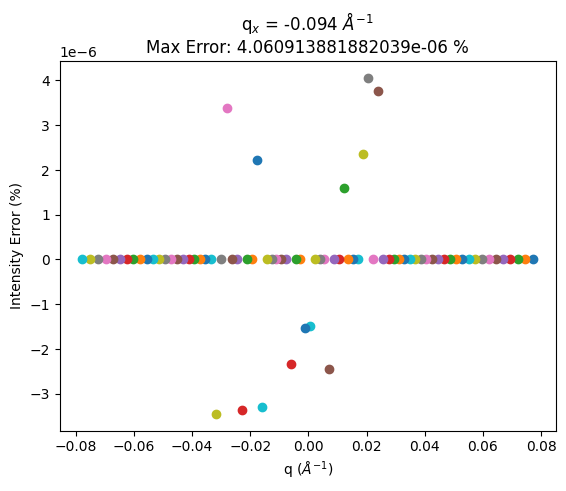

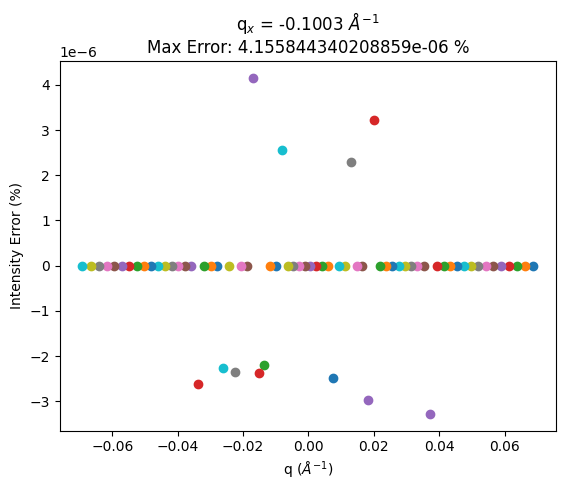

In [53]:
# plot error between the refactored code and legacy gui slices
# the intensity from the refactored code is divided by 2 (the count time in seconds) as this normalization feature is not yet available in the refactored code
%matplotlib inline
all_max_errors = []
for qx in legacy_slices.keys():
    plt.figure()
    slice_legacy = legacy_slices[qx]
    slice_refactor = refactored_slices[qx]

    max_error = 0
    for i, q in enumerate(slice_legacy.q):
        close_match = np.argmin(np.abs(slice_refactor.q - q))
        q_close = slice_refactor.q[close_match]
        # only match up pairs that are sufficiently close in q
        q_error = np.abs((q-q_close)*100/q)
        if q_error <= 0.1:
            error = (slice_refactor.Iq[close_match] - slice_legacy.Iq[i])*100/slice_legacy.Iq[i]
            plt.scatter(q, error)
            if np.abs(error) > np.abs(max_error):
                max_error = error

    all_max_errors.append(max_error)
    # plt.xlim(-0.001, 0.001)
    
    plt.title(r"q$_x$ = "+str(qx)+r" $\AA^{-1}$"+"\nMax Error: "+str(np.abs(max_error))+" %")
    plt.ylabel("Intensity Error (%)")
    plt.xlabel(r"q ($\AA^{-1}$)")
    plt.show()
    plt.close()

    # break

In [54]:
# Maximum error ( % absolute intensity) from all slices:
np.max(np.abs(all_max_errors))

np.float64(1.3298571222785538e-05)